![Logo UOC](https://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/logotips/logo-UOC-2linies.png)

# TFG - Inteligencia Artificial
Enero de 2026

## Predicción de Respuesta a Tratamientos Oncológicos Basada en el Perfil Genético Mediante Técnicas de Aprendizaje Automático (ML) e Identificación de Genes Candidatos a Biomarcador Usando Técnicas de Explicabilidad (XAI) y Cuantificación de la Incertidumbre (UQ)

---

#### Pablo Vázquez Rodríguez
##### Grado en Ingeniería Informática
##### Inteligencia Artificial

#### Dra. María Moreno de Castro
#### Dr. Friman Sánchez

---

## Modelado (Paso 2): Entrenamiento de modelos

Como ya se comentó en el documento de exploración y preparación de datos durante el modelado se harán estas tareas:
1. Selección de características supervisada
2. Entrenamiento de modelos
3. Calibración del modelo
4. Análisis y selección del modelo optimizado

Durante la primera tarea se realiza una selección de genes basada en modelos de regresión logística, Random Forest, XGBoost y CatBoost, con filtrado no supervisado mediante Elbow/K-Means.

Durante la segunda tarea, se entrenan los modelos de nuevo esta vez sobre el conjunto que contiene sólo a los genes seleccionados. 

Durante la tercera tarea, tras el entrenamiento, se calibran los modelos.

Durante la cuarta tarea se hace un análisis de los modelos obtenidos, se valora su rendimiento, incertidumbre y se elige el modelo óptimo para los objetivos del proyecto.

## 0. Operaciones previas

### Carga de librerías necesarias

In [7]:
import pandas as pd
import numpy as np
import optuna
from optuna.visualization import (
    plot_optimization_history, plot_param_importances, plot_edf, plot_slice)
from plotly.subplots import make_subplots
import joblib
from datetime import datetime
from scipy import stats
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from aux.ml_core import optimization, training

### Configuraciones iniciales

In [2]:
# Random generator de numpy con seed para reproducibilidad en el notebook
rng_seed = 19293
rng = np.random.default_rng(seed=rng_seed)

In [3]:
# Carga de los datasets
df_full = pd.read_csv("./data/final/full_top_significance_reduced_feat.csv")
df_train = pd.read_csv("./data/final/train_reduced_feat.csv")
df_test = pd.read_csv("./data/final/test_reduced_feat.csv")
df_cal = pd.read_csv("./data/final/cal_reduced_feat.csv")
df_scaled_train = pd.read_csv("./data/final/scaled_train_reduced_feat.csv")
df_scaled_test = pd.read_csv("./data/final/scaled_test_reduced_feat.csv")
df_scaled_cal = pd.read_csv("./data/final/scaled_cal_reduced_feat.csv")

In [4]:
# VARIABLES ÚTILES

# Nombres de las columnas de genes
gene_columns = df_full.columns.difference(["Sample_id", "Response"])

### Modelado

In [10]:
# Crear los folds para la validación cruzada para garantizar que todos usan 
# el mismo fold de la misma forma y el objeto es exactamente el mismo para todos
training_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rng_seed)
training_folds = list(training_cv.split(X_train, y_train))

In [11]:
# Datos de entrenamiento
X_train = df_scaled_train.drop(columns=["Response", "Sample_id"])
y_train_orig = df_scaled_train["Response"]

# Datos de test
X_test = df_scaled_test.drop(columns=["Response", "Sample_id"])
y_test_orig = df_scaled_test["Response"]

# Datos de calibración
X_cal = df_scaled_cal.drop(columns=["Response", "Sample_id"])
y_cal_orig = df_scaled_cal["Response"]

# Para simplificar el modelado con la función auxiliar, se decide en este punto
# transformar Response de Categórica a 0/1

# Clases objetivo a 0/1: Non_response=0, Response=1
le = LabelEncoder()
y_train = le.fit_transform(y_train_orig)
y_test = le.fit_transform(y_test_orig)
y_cal = le.fit_transform(y_cal_orig)

# Mostrar mapeo de clases
for i, label in enumerate(le.classes_): print(f"{i}: {label}")

0: Non_response
1: Response


In [12]:
# NOTA: Esta celda tarda alrededor de 3 minutos en el hardware original usado
# Modelo de Regresión logística para selección de genes

# Fecha y hora de la ejecución (para que los nombres de estudio siempre sean únicos)
now = datetime.now().isoformat()
study_name = f"{now}_best_logreg_model_study"

# Estimador
logreg = LogisticRegression(penalty="elasticnet", solver="saga", max_iter=5000, class_weight="balanced")

# Rangos de hiperparámetros
logreg_param_grid = {
    "C":        ["F", 0.0001, 10.0, {"log": True}], 
    "l1_ratio": ["F", 0.1, 0.9, {}]}

# Mejores hiperparámetros encontrados
logreg_best_hiperparameters_data = optimization.optimize_hyperparameters(
    logreg, logreg_param_grid, X_train, y_train, n_trials=150, folds=training_folds, rng_seed=rng_seed, 
    study_name=study_name, store_study=True)

[I 2025-12-23 05:30:43,253] A new study created in RDB with name: 2025-12-23T05:30:42.848671_best_logreg_model_study
[I 2025-12-23 05:30:44,272] Trial 0 finished with value: 0.5431100082712985 and parameters: {'C': 0.0005022820395846325, 'l1_ratio': 0.17724266701393906}. Best is trial 0 with value: 0.5431100082712985.
[I 2025-12-23 05:30:45,315] Trial 1 finished with value: 0.5841264795486103 and parameters: {'C': 0.14733475485510036, 'l1_ratio': 0.17761393379489734}. Best is trial 1 with value: 0.5841264795486103.
[I 2025-12-23 05:30:46,357] Trial 2 finished with value: 0.5908885374743621 and parameters: {'C': 3.7037257449165017, 'l1_ratio': 0.3075058386412011}. Best is trial 2 with value: 0.5908885374743621.
[I 2025-12-23 05:30:47,360] Trial 3 finished with value: 0.5431100082712985 and parameters: {'C': 0.0001687066326701612, 'l1_ratio': 0.5430724822091214}. Best is trial 2 with value: 0.5908885374743621.
[I 2025-12-23 05:30:48,375] Trial 4 finished with value: 0.5797926891182383 an

In [13]:
print(f"**Estudio (Optuna)**: {study_name}",
    f"\n\n**Mejores parámetros**: {logreg_best_hiperparameters_data["best_params"]}",
      f"\n\n**F1**:", logreg_best_hiperparameters_data["best_score"],
      f"\n\n**Intervalo de scores F1**: ", logreg_best_hiperparameters_data["best_score_interval"])

**Estudio (Optuna)**: 2025-12-23T05:30:42.848671_best_logreg_model_study 

**Mejores parámetros**: {'C': 2.9572029517344083, 'l1_ratio': 0.8695927259963505} 

**F1**: 0.5933910528325129 

**Intervalo de scores F1**:  (0.5775862068965517, 0.6111111111111112)


**Valores obtenidos**

**Estudio (Optuna)**: 2025-12-23T05:30:42.848671_best_logreg_model_study 

**Mejores parámetros**: {'C': 2.9572029517344083, 'l1_ratio': 0.8695927259963505} 

**F1**: 0.5933910528325129 

**Intervalo de scores F1**:  (0.5775862068965517, 0.6111111111111112)

In [16]:
# Mejor modelo de Regresión Logística
best_logreg_model = training.train_with_best_params(
    logreg, logreg_best_hiperparameters_data['best_params'], X_train, y_train, rng_seed=rng_seed)["final_model"]
# Guardar el mejor modelo para usarlo en posteriores análisis
# NOTA: Comentado para evitar guardados de nuevos modelos accidentalmente
#joblib.dump(best_logreg_model, f"./data/best_models/best_logreg_model.joblib")

['./data/best_models/best_logreg_model.joblib']

**Random Forest**

In [17]:
# NOTA: Esta celda tarda alrededor de 20 minutos en el hardware original usado
# Modelo de Regresión logística para selección de genes

# Fecha y hora de la ejecución (para que los nombres de estudio siempre sean únicos)
now = datetime.now().isoformat()
study_name = f"{now}_best_rf_model_study"

# Estimador
rf = RandomForestClassifier(class_weight="balanced", random_state=rng_seed)

# Rangos de hiperparámetros
rf_param_grid = {
    "n_estimators": ["I", 100, 600, {}],
    "max_depth": ["I", 5, 20, {}],
    "max_features": ["C", "sqrt", "log2", 0.05, 0.1, 0.2, {}],
    "min_samples_split": ["I", 2, 20, {}],
    "min_samples_leaf": ["I", 1, 20, {}],
}

# Mejores hiperparámetros encontrados
rf_best_hiperparameters_data = optimization.optimize_hyperparameters(
    rf, rf_param_grid, X_train, y_train, n_trials=150, folds=training_folds, rng_seed=rng_seed, 
    study_name=study_name, store_study=True)

[I 2025-12-23 05:36:20,704] A new study created in RDB with name: 2025-12-23T05:36:20.628736_best_rf_model_study
[I 2025-12-23 05:36:25,105] Trial 0 finished with value: 0.6156407590084619 and parameters: {'n_estimators': 377, 'max_depth': 17, 'max_features': 0.05, 'min_samples_split': 10, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.6156407590084619.
[I 2025-12-23 05:36:31,033] Trial 1 finished with value: 0.6364204068004938 and parameters: {'n_estimators': 455, 'max_depth': 20, 'max_features': 0.05, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.6364204068004938.
[I 2025-12-23 05:36:37,896] Trial 2 finished with value: 0.6208371507711716 and parameters: {'n_estimators': 403, 'max_depth': 9, 'max_features': 'sqrt', 'min_samples_split': 18, 'min_samples_leaf': 19}. Best is trial 1 with value: 0.6364204068004938.
[I 2025-12-23 05:36:40,304] Trial 3 finished with value: 0.624898033037568 and parameters: {'n_estimators': 103, 'max_depth': 5, 'max_f

In [18]:
print(f"**Estudio (Optuna)**: {study_name}",
    f"\n\n**Mejores parámetros**: {rf_best_hiperparameters_data["best_params"]}",
      f"\n\n**F1**:", rf_best_hiperparameters_data["best_score"],
      f"\n\n**Intervalo de scores F1**: ", rf_best_hiperparameters_data["best_score_interval"])

**Estudio (Optuna)**: 2025-12-23T05:36:20.628736_best_rf_model_study 

**Mejores parámetros**: {'n_estimators': 233, 'max_depth': 17, 'max_features': 0.2, 'min_samples_split': 11, 'min_samples_leaf': 2} 

**F1**: 0.6456096926833015 

**Intervalo de scores F1**:  (0.6204081632653061, 0.6864406779661016)


**Valores obtenidos**

**Estudio (Optuna)**: 2025-12-23T05:36:20.628736_best_rf_model_study 

**Mejores parámetros**: {'n_estimators': 233, 'max_depth': 17, 'max_features': 0.2, 'min_samples_split': 11, 'min_samples_leaf': 2} 

**F1**: 0.6456096926833015 

**Intervalo de scores F1**:  (0.6204081632653061, 0.6864406779661016)

In [21]:
# Mejor modelo de Random Forest
best_rf_model = training.train_with_best_params(
    rf, rf_best_hiperparameters_data['best_params'], X_train, y_train, rng_seed=rng_seed)["final_model"]

# Guardar el mejor modelo para usarlo en posteriores análisis
# NOTA: Comentado para evitar guardados de nuevos modelos accidentalmente
#joblib.dump(best_rf_model, f"./data/best_models/best_rf_model.joblib")

['./data/best_models/best_rf_model.joblib']

**XGBoost**

In [20]:
# NOTA: Esta celda tarda alrededor de 6 minutos en el hardware original usado
# Modelo de Regresión logística para selección de genes

# Fecha y hora de la ejecución (para que los nombres de estudio siempre sean únicos)
now = datetime.now().isoformat()
study_name = f"{now}_best_xgboost_model_study"

# Ratio de balanceo (0=Non_response, 1=Response)
balance_value = (y_train==0).sum() / (y_train==1).sum()

# Estimador
xgboost = XGBClassifier(scale_pos_weight=balance_value, random_state=rng_seed)

# Rangos de hiperparámetros
xgboost_param_grid = {
    "n_estimators": ["I", 200, 1000, {}],
    "max_depth": ["I", 2, 6, {}],
    "learning_rate": ["F", 0.01, 0.3, {"log": True}],
    "min_child_weight": ["I", 1, 10, {}],
    "reg_alpha": ["F", 0.001, 10.0, {"log": True}],
    "reg_lambda": ["F", 0.001, 100.0, {"log": True}],
    "subsample": ["F", 0.5, 1.0, {}],
    "colsample_bytree": ["F", 0.1, 0.8, {}],
    "gamma": ["F", 0.0, 10.0, {}]
}

# Mejores hiperparámetros encontrados
xgboost_best_hiperparameters_data = optimization.optimize_hyperparameters(
    xgboost, xgboost_param_grid, X_train, y_train, n_trials=150, folds=training_folds, rng_seed=rng_seed, 
    study_name=study_name, store_study=True)

[I 2025-12-23 05:45:06,484] A new study created in RDB with name: 2025-12-23T05:45:06.437146_best_xgboost_model_study
[I 2025-12-23 05:45:08,278] Trial 0 finished with value: 0.6218841791217132 and parameters: {'n_estimators': 478, 'max_depth': 5, 'learning_rate': 0.10646350050131509, 'min_child_weight': 9, 'reg_alpha': 0.08613261970160514, 'reg_lambda': 0.08576797956635368, 'subsample': 0.9643407801616612, 'colsample_bytree': 0.6255756036188683, 'gamma': 3.2189620919792947}. Best is trial 0 with value: 0.6218841791217132.
[I 2025-12-23 05:45:12,263] Trial 1 finished with value: 0.6052190609497579 and parameters: {'n_estimators': 785, 'max_depth': 2, 'learning_rate': 0.022052586254820056, 'min_child_weight': 10, 'reg_alpha': 0.03924753630723195, 'reg_lambda': 34.15398136732836, 'subsample': 0.7503087203104131, 'colsample_bytree': 0.4195138121934642, 'gamma': 5.70135720631484}. Best is trial 0 with value: 0.6218841791217132.
[I 2025-12-23 05:45:14,799] Trial 2 finished with value: 0.628

In [36]:
print(f"**Estudio (Optuna)**: {study_name}",
    f"\n\n**Mejores parámetros**: {xgboost_best_hiperparameters_data["best_params"]}",
      f"\n\n**F1**:", xgboost_best_hiperparameters_data["best_score"],
      f"\n\n**Intervalo de scores F1**: ", xgboost_best_hiperparameters_data["best_score_interval"])

**Estudio (Optuna)**: 2025-12-23T05:49:50.187119_best_catboost_model_study 

**Mejores parámetros**: {'n_estimators': 645, 'max_depth': 6, 'learning_rate': 0.04269416688188391, 'min_child_weight': 5, 'reg_alpha': 0.0010122171661582713, 'reg_lambda': 0.007249544721553679, 'subsample': 0.5020579643247725, 'colsample_bytree': 0.6033017565343983, 'gamma': 4.448209828162774} 

**F1**: 0.6396684818467095 

**Intervalo de scores F1**:  (0.6136363636363636, 0.684931506849315)


**Valores obtenidos**

**Estudio (Optuna)**: 2025-12-23T05:45:06.437146_best_xgboost_model_study 

**Mejores parámetros**: {'n_estimators': 645, 'max_depth': 6, 'learning_rate': 0.04269416688188391, 'min_child_weight': 5, 'reg_alpha': 0.0010122171661582713, 'reg_lambda': 0.007249544721553679, 'subsample': 0.5020579643247725, 'colsample_bytree': 0.6033017565343983, 'gamma': 4.448209828162774} 

**F1**: 0.6396684818467095 

**Intervalo de scores F1**:  (0.6136363636363636, 0.684931506849315)

In [23]:
# Mejor modelo de XGBoost
best_xgboost_model = training.train_with_best_params(
    xgboost, xgboost_best_hiperparameters_data['best_params'], X_train, y_train, rng_seed=rng_seed)["final_model"]

# Guardar el mejor modelo para usarlo en posteriores análisis
# NOTA: Comentado para evitar guardados de nuevos modelos accidentalmente
#joblib.dump(best_xgboost_model, f"./data/best_models/best_xgboost_model.joblib")

['./data/best_models/best_xgboost_model.joblib']

**CatBoost**

In [24]:
# NOTA: Esta celda tarda alrededor de 7 minutos en el hardware original usado
# Modelo de Regresión logística para selección de genes

# Fecha y hora de la ejecución (para que los nombres de estudio siempre sean únicos)
now = datetime.now().isoformat()
study_name = f"{now}_best_catboost_model_study"

# Ratio de balanceo (0=Non_response, 1=Response)
balance_value = (y_train==0).sum() / (y_train==1).sum()

# Estimador
catboost = CatBoostClassifier(
    class_weights=[1, balance_value], early_stopping_rounds=50, random_state=rng_seed)

# Rangos de hiperparámetros
catboost_param_grid = {
    "iterations": ["I", 200, 1000, {}],
    "depth": ["I", 2, 8, {}],
    "learning_rate": ["F", 0.01, 0.3, {"log": True}],
    "l2_leaf_reg": ["F", 1.0, 50.0, {"log": True}],
    "border_count": ["I", 32, 255, {}],
    "rsm": ["F", 0.8, 1.0, {}]
}

# Mejores hiperparámetros encontrados
catboost_best_hiperparameters_data = optimization.optimize_hyperparameters(
    catboost, catboost_param_grid, X_train, y_train, n_trials=150, folds=training_folds, rng_seed=rng_seed, 
    study_name=study_name, store_study=True)

[I 2025-12-23 05:49:50,232] A new study created in RDB with name: 2025-12-23T05:49:50.187119_best_catboost_model_study
[I 2025-12-23 05:49:53,636] Trial 0 finished with value: 0.6318163005018954 and parameters: {'iterations': 461, 'depth': 5, 'learning_rate': 0.016138145724084913, 'l2_leaf_reg': 2.641391339381048, 'border_count': 49, 'rsm': 0.9292899219562962}. Best is trial 0 with value: 0.6318163005018954.
[I 2025-12-23 05:49:59,375] Trial 1 finished with value: 0.639218528903369 and parameters: {'iterations': 900, 'depth': 8, 'learning_rate': 0.0187050829256432, 'l2_leaf_reg': 18.45268989218778, 'border_count': 49, 'rsm': 0.8566380322397515}. Best is trial 1 with value: 0.639218528903369.
[I 2025-12-23 05:50:01,622] Trial 2 finished with value: 0.6408698693977268 and parameters: {'iterations': 677, 'depth': 6, 'learning_rate': 0.07604788094544235, 'l2_leaf_reg': 5.5342659492487485, 'border_count': 60, 'rsm': 0.8598551159383178}. Best is trial 2 with value: 0.6408698693977268.
[I 202

In [35]:
print(f"**Estudio (Optuna)**: {study_name}",
    f"\n\n**Mejores parámetros**: {catboost_best_hiperparameters_data["best_params"]}",
      f"\n\n**F1**:", catboost_best_hiperparameters_data["best_score"],
      f"\n\n**Intervalo de scores F1**: ", catboost_best_hiperparameters_data["best_score_interval"])

**Estudio (Optuna)**: 2025-12-23T05:49:50.187119_best_catboost_model_study 

**Mejores parámetros**: {'iterations': 649, 'depth': 8, 'learning_rate': 0.06953212502022214, 'l2_leaf_reg': 1.0047858272648311, 'border_count': 47, 'rsm': 0.8226220591598365} 

**F1**: 0.6510875816428066 

**Intervalo de scores F1**:  (0.61003861003861, 0.68)


**Estudio (Optuna)**: 2025-12-23T05:49:50.187119_best_catboost_model_study 

**Mejores parámetros**: {'iterations': 649, 'depth': 8, 'learning_rate': 0.06953212502022214, 'l2_leaf_reg': 1.0047858272648311, 'border_count': 47, 'rsm': 0.8226220591598365} 

**F1**: 0.6510875816428066 

**Intervalo de scores F1**:  (0.61003861003861, 0.68)

In [27]:
# Mejor modelo de CatBoost
best_catboost_model = training.train_with_best_params(
    catboost, catboost_best_hiperparameters_data['best_params'], X_train, y_train, rng_seed=rng_seed)["final_model"]

# Guardar el mejor modelo para usarlo en posteriores análisis
# NOTA: Comentado para evitar guardados de nuevos modelos accidentalmente
joblib.dump(best_catboost_model, f"./data/best_models/best_catboost_model.joblib")

0:	learn: 0.6796853	total: 3.27ms	remaining: 2.12s
1:	learn: 0.6635449	total: 10.9ms	remaining: 3.52s
2:	learn: 0.6511353	total: 17.1ms	remaining: 3.68s
3:	learn: 0.6402592	total: 22.3ms	remaining: 3.6s
4:	learn: 0.6327403	total: 26ms	remaining: 3.34s
5:	learn: 0.6226707	total: 29.9ms	remaining: 3.21s
6:	learn: 0.6154984	total: 34.1ms	remaining: 3.13s
7:	learn: 0.6083924	total: 38.4ms	remaining: 3.08s
8:	learn: 0.5993825	total: 41.7ms	remaining: 2.96s
9:	learn: 0.5943424	total: 44.9ms	remaining: 2.87s
10:	learn: 0.5881704	total: 47.9ms	remaining: 2.78s
11:	learn: 0.5786645	total: 49.5ms	remaining: 2.63s
12:	learn: 0.5729254	total: 51.1ms	remaining: 2.5s
13:	learn: 0.5667869	total: 53.7ms	remaining: 2.43s
14:	learn: 0.5618708	total: 55.4ms	remaining: 2.34s
15:	learn: 0.5528087	total: 56.7ms	remaining: 2.24s
16:	learn: 0.5468929	total: 58.3ms	remaining: 2.17s
17:	learn: 0.5417603	total: 60ms	remaining: 2.1s
18:	learn: 0.5353946	total: 63.9ms	remaining: 2.12s
19:	learn: 0.5300877	total: 6

['./data/best_models/best_catboost_model.joblib']

**A continuación se muestran algunos ejemplos que evidencian cómo Optuna va haciendo la búsqueda de hiperparámetros para Regresión Logística**

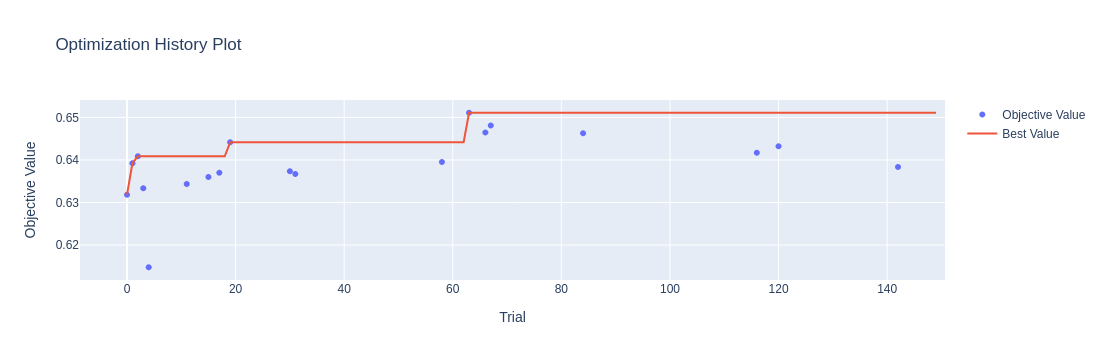

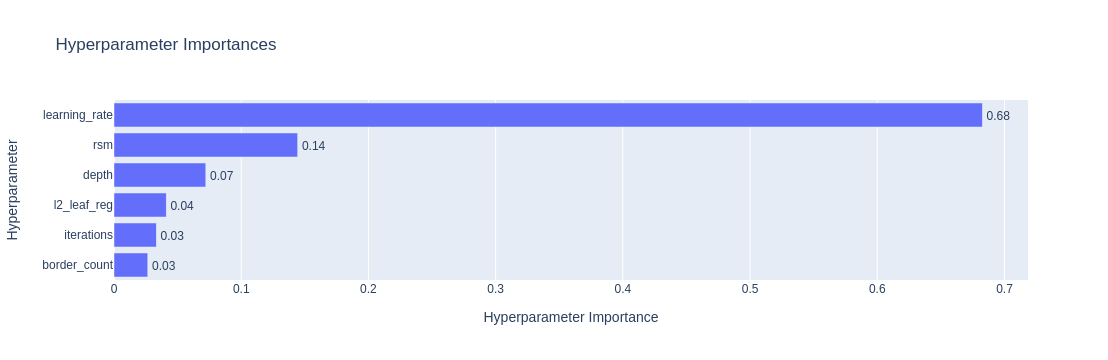

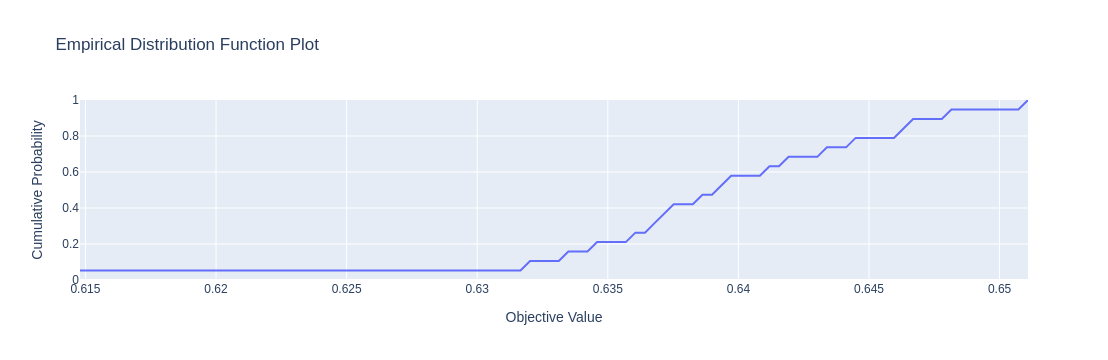

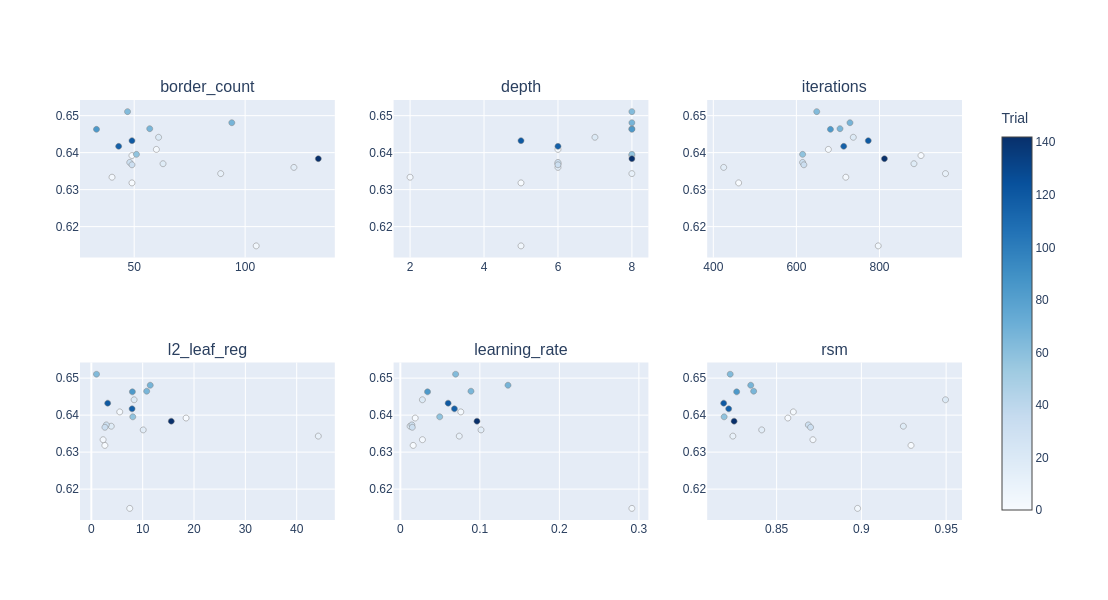

In [34]:
study_of_model_to_graph = catboost_best_hiperparameters_data["study"]

# Gráfico de evolución
fig1 = plot_optimization_history(study_of_model_to_graph)
fig1.show()

# Gráfico de importancia de parámetros
fig2 = plot_param_importances(study_of_model_to_graph)
fig2.show()

# Gráfico de coordenadas paralelas
fig3 = plot_edf(study_of_model_to_graph)
fig3.show()

# Gráfico de evolución de la búsqueda de hiperparámetros
fig4 = plot_slice(study_of_model_to_graph)
# Extraer títulos de los ejes X (los parámetros)
param_names = []
for key in fig4.layout:
    if key.startswith("xaxis"):
        title = getattr(fig4.layout[key].title, "text", None)
        if title:
            param_names.append(title)
param_names.sort()
# Crear una rejilla personalizada de 2 filas x 3 columnas
custom_fig = make_subplots(rows=2, cols=3, subplot_titles=param_names)

# Añadir cada trace en la rejilla
row, col = 1, 1
traces = fig4.data
for trace in traces:
    custom_fig.add_trace(trace, row=row, col=col)
    col += 1
    if col > 3:  # pasar a la siguiente fila
        col = 1
        row += 1

custom_fig.update_layout(height=600, width=800)

# Mostrar la figura
custom_fig.show()

**NOTA**: Como en este notebook hay mucha celda pesada, se procederá al análisis de los modelos en el siguiente notebook